## all current generators and readouts


## Setup Qick Emulator


In [1]:
import sys
import importlib
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Local Qick path setup
REPO_ROOT  = pathlib.Path.cwd().parent          # emulator/
sys.path.insert(0,str(REPO_ROOT / '..' / 'qick_lib/'))
# Local QickEmu path setup
source_dir = REPO_ROOT / 'software'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))
# # Display current sys.path
# print(sys.path)


import qick_emu
importlib.reload(qick_emu)          # pick up edits without kernel restart
from qick_emu import QickEmu

from qick.asm_v2 import AveragerProgramV2, QickSpan, QickSweep1D


## QICKEmu Auxiliary Functions
def QICKEmu_plot_dac(soc_emu, OUT):
    # DAC waveform
    t_dac, dac = soc_emu.load_dac(OUT, absolute_time=True)
    t_dac_ch1, dac_ch1 = soc_emu.load_dac(emu_dir=OUT, gen_ch=1, absolute_time=True)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac, dac, linewidth=0.8)
    plt.plot(t_dac_ch1, dac_ch1, linewidth=0.8)
    plt.xlabel('time [us]'); plt.ylabel('DAC value'); plt.title('DAC output')
    plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

def QICKEmu_plot_dac2(soc_emu, OUT):
    # DAC waveform
    t_dac_ch2, dac_ch2 = soc_emu.load_dac(emu_dir=OUT, gen_ch=2, absolute_time=True)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac_ch2, dac_ch2, linewidth=0.8)
    plt.xlabel('time [us]'); plt.ylabel('DAC2 value'); plt.title('DAC2 output')
    plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

## Setup

In [2]:
# jupyter setup boilerplate
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from qick import *

# for now, all the tProc v2 classes need to be individually imported (can't use qick.*)

# the main program class
from qick.asm_v2 import AveragerProgramV2
# for defining sweeps
from qick.asm_v2 import QickSweep1D
# for adding code snippets in loop exec_before/exec_after
from qick.asm_v2 import AsmV2

## firmware
This demo is using the firmware in https://s3df.slac.stanford.edu/people/meeg/qick/tprocv2/2024-09-03_216_tprocv2r21_demo/.
The firmware project files are also there; the project was compiled with core revision 21 of the tProc v2.
This is a ZCU216 firmware.

This firmware is sort of similar to the old "q3diamond" firmware, in that it has a lot of different generators and readouts (it's intended to cover the full range of currently recommended blocks). Some generators and readouts are new; the old versions are still available for use if you want them in your firmware, and both tProc v1 and v2 support all generators and readouts.
* one standard fullspeed generator (axis_signal_gen_v6)
* two interpolated generators (axis_sg_int4_v2)
    * this is a new version, but the only change from axis_sg_int4_v1 is that the frequency and phase now have 32-bit resolution.
* two different muxed generators, both new
    * axis_sg_mux8_v1 - I'll call this the "fullspeed-mux" generator because it doesn't use the DAC digital mixer
        * it can play up to 8 tones
        * full phase coherence
        * you can set the tone phases
        * it doesn't use the digital mixer, so the DAC can have a sampling frequency up to 10 Gsps; the bad news is that this uses way more FPGA resources and this generator won't fit on the FPGA if you want a lot of other generators as well
    * axis_sg_mixmux8_v1 - I'll call this the "mixer-mux" because it's the same as axis_sg_mux8_v1 but with the digital mixer (similar to the old axis_sg_mux4_v2), so it's 8 tones, fully phase-coherent, configurable phase, goes up to 7 Gsps
        * because it uses 1/4 the FPGA resources of axis_sg_mux8_v1, this will be the preferred mux generator
* one standard readout (axis_readout_v2)
* two different dynamically configured (aka tProc-configured) readouts
    * axis_readout_v3 - I'll call this the "fast dynamic RO," this is the one we've had for a while for phase-reset readout, where you can do a synchronous phase reset on this RO and a generator with 4x the sampling frequency, but it's somewhat quirky and annoying to place in firmware; 
    * axis_dyn_readout_v1 - I'll call this the "dynamic RO," this is a clone of the standard readout but with dynamic control, and might become our new standard readout (the only clear downside is that it consumes a tProc output); much simpler than axis_readout_v3, you can still do synchronous phase reset but the ratio of sampling freqs needs to be 1:2 which is probably less useful
* one muxed readout (axis_pfb_readout_v3) - this is a new one:
    * finer channel spacing, the ADC Nyquist zone is divided into 64 slices instead of 8
    * full phase coherence
    * the ability to take two outputs from a single channel (you will still see lots of crosstalk if you play two tones simultaneously in the same channel; you'll get a warning if your readout frequencies put you at danger of this)
    * you can set the downconversion phase (this is also possible on the standard and tProc-configured readouts)
    * there's a version (axis_pfb_readout_v4) with 8 outputs instead of 4, otherwise identical
 
This firmware also uses the "tProc mux" which allows multiple blocks to be controlled by the same tProc output. Since blocks on a mux share a tProc output and its timed queue, commands to multiple blocks on the same mux must be queued in schedule order, and if you schedule two commands for the same time the second one is going to get delayed.
The tmux will only be needed in firmwares where the total number of generators and dynamic readouts exceeds 16; since there are only 16 DACs, the excess can only come from dynamic ROs. In these cases I plan to tmux the dynamic ROs together (this is safe because RO configuration is usually not timing-critical) with a mux generator (this is safe because mux generators are usually not read out with dynamic RO).

Some general comments (not specific to tProc v2):
* You can always mix and match generators and readouts to suit your RF setup and experimental needs. This demo matches them up in a certain arbitrary way, but this is not the law.
* "Full phase coherence" is my new shorthand for "phase-coherent with respect to frequency changes."
    * All QICK generators and readouts are phase-coherent in the sense that if you play (or downconvert) a pulse, wait a while, and repeat, the carrier LO will maintain its phase just as if it had been running continuously. In terms of qubit control, this means that the carrier phase will track the qubit phase, and your X-gate will always be an X-gate.
    * Some generators and readouts (for example, the standard generator and readout) are fully phase-coherent: if you change the carrier frequency the phase will change in a predictable way, and when you change the frequency back, the phase will go back just as if you had never changed the frequency. This allows you to do frequency scans and get meaningful phase information.
    * Some generators and readouts (for example, the old muxed generator and readout - mux4_v2 and pfb_readout_v2), and the digital mixer, are not fully phase-coherent. These are phase-continuous: if you change the frequency, the phase doesn't jump. But that is not a useful property for us. These are OK for qubit readout once you know what frequencies to use, but you will probably want to do your resonator spectroscopy with a different channel or firmware where you have full phase coherence.
 
***While I have listed the different generators and readouts here, this is not a full description of what each does and how it is used.***
* Please pay attention below where I talk about each and walk through example code.
* I am assuming some prior familiarity with the non-standard generators and readouts here, because my expectation was that people would start by using tProc v2 versions of firmwares they were already familiar with. Things evolved differently. For public release we will need to have "from the ground up" descriptions of each of the blocks, but I did not do that here, sorry.
* *If you want to do in-program sweeps of your readout frequency, you need to use a dynamic readout. That's essentially what "dynamic" means.*

I've set things up with three loopbacks, approximately as shown:
* DAC 0_230 to ADC 0_226, 10MHz-1GHz baluns (fullspeed gen to dynamic RO), with an SMA tee with a short piece of unterminated cable (to act as a resonator) - note that this isn't what's shown in the photo (which is old), I changed baluns, removed the filter, and swapped the barrels for the cable to get a lower frequency.
* DAC 2_230 to ADC 2_226, 10MHz-1GHz baluns (fullspeed-mux gen to mux RO)
* DAC 0_231 to ADC 3_226, 1-4 GHz baluns (interpolated gen to standard RO)
* not cabled: mixer-mux gen on DAC 2_231, fast dynamic RO on ADC 1_226

![image.png](01_gens-and-readouts_photo.jpg)

In [3]:
# emulator init
# CFG_PATH = REPO_ROOT / 'config' / 'qick_config_216.json'
CFG_PATH = REPO_ROOT / 'config' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# artifact root
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '01_gens-and-readouts'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

# Master switch — set False to skip Verilator runs and re-plot from existing CSVs
RUN_SIM = True

print(f'REPO_ROOT     : {REPO_ROOT}')
print(f'ARTIFACTS_ROOT: {ARTIFACTS_ROOT}')
print(soccfg)

# Default Path is the artifacts root.
OUT = ARTIFACTS_ROOT


QICK library version mismatch: 0.2.366 remote (the board), 0.2.87 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


REPO_ROOT     : /home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator
ARTIFACTS_ROOT: /home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/artifacts/01_gens-and-readouts
QICK running on QICKEmu, software version 0.2.366

Firmware configuration (built Sat Sep 28 22:15:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	3 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is QICKEmu DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is QICKEmu DAC port 1
	2:	axis_sg_mux8_v1 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex sampl

In [4]:
FSGEN_CH = 0
INTGEN_CH = 1
FSMUXGEN_CH = 2
# MIXMUXGEN_CH = 4

DYNRO_CH = 0
# MUXRO_CH = [2,3,4,5]
MUXRO_CH = [2]
STDRO_CH = 6
FASTDYNRO_CH = 1

### Muxed generator and muxed readout
Since we only have 4 outputs on the mux readout in this firmware, we'll only play 4 tones on the mux generator. But you could play 8 tones.

Note that finer channel spacing on the mux readout means less bandwidth per channel, and a correspondingly lower sample rate on the decimated data.

In [9]:
class MuxProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_chs[0], 
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'], 
                         mux_phases=cfg['pulse_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=gen_ch)
        # self.declare_readout(ch=ro_chs[0], length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mymux", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0,1,2,3],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name="mymux", t=0)
        
config = {'gen_ch': FSMUXGEN_CH,
          'ro_chs': MUXRO_CH,
          'pulse_freqs': [50, 0, 0, 0],
          'pulse_gains': [1.0]*4,
          'pulse_phases': [0.0]*4,
          'ro_phases': [0.0]*4,
          'trig_time': 0.4,
          'pulse_len': 1.0,
          'ro_len': 1.9,
         }

prog = MuxProgram(soccfg, reps=1, final_delay=0.5, cfg=config)


Artifacts -> /home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/artifacts/01_gens-and-readouts/MuxProgram
[verilate] Building QICKEmu_harness ...
/home/dmartin2/hrl-labs-clinic/verilator_v5.042/bin/verilator --binary --exe --build -j 0 -Wall --trace --Wno-fatal --error-limit 1 --timing -Wno-DECLFILENAME -Wno-PINCONNECTEMPTY -Wno-VARHIDDEN -Wno-TIMESCALEMOD -Wno-EOFNEWLINE -Wno-WIDTH -Wno-PINMISSING -Wno-BADVLTPRAGMA -Wno-CONSTRAINTIGN -I../../emulator/submodules/pulp_platform/axi/include -I../../emulator/submodules/pulp_platform/common_verification/include -I../../emulator/submodules/pulp_platform/common_cells/include -I../../firmware/ip/qick_processor/src -y ../../emulator/models/bram_dp -y ../../emulator/models/fifo -y ../../emulator/models/dac_model -y ../../emulator/models/dds_model -y ../../emulator/models/dds_model/src -y ../../firmware/ip/common -y ../../firmware/ip/qick_common verilator.vlt --top-module QICKEmu_harness -work lib_axis_pfb_readout_v3 ../../firmwar

%Warning-MODDUP: ../../firmware/ip/axis_readout_v2/src/down_conversion_fir.v:1:8: Duplicate declaration of module: 'down_conversion_fir'
    1 | module down_conversion_fir #(
      |        ^~~~~~~~~~~~~~~~~~~
                 ../../firmware/ip/axis_dyn_readout_v1/src/down_conversion_fir.v:1:8: ... Location of original declaration
    1 | module down_conversion_fir (
      |        ^~~~~~~~~~~~~~~~~~~
                 ... For warning description see https://verilator.org/warn/MODDUP?v=5.042
                 ... Use "/* verilator lint_off MODDUP */" and lint_on around source to disable this message.
%Warning-MODDUP: ../../firmware/ip/axis_readout_v2/src/down_conversion.v:1:8: Duplicate declaration of module: 'down_conversion'
    1 | module down_conversion #(
      |        ^~~~~~~~~~~~~~~
                 ../../firmware/ip/axis_dyn_readout_v1/src/down_conversion.v:1:8: ... Location of original declaration
    1 | module down_conversion (
      |        ^~~~~~~~~~~~~~~
%Warning-MODDUP: 

make[1]: Entering directory '/home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/testbench/obj_dir'
g++ -Os  -I.  -MMD -I/home/dmartin2/hrl-labs-clinic/verilator_v5.042/include -I/home/dmartin2/hrl-labs-clinic/verilator_v5.042/include/vltstd -DVERILATOR=1 -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TIMING=1 -DVM_TRACE=1 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=1 -DVM_TRACE_SAIF=0 -faligned-new -fcf-protection=none -Wno-bool-operation -Wno-int-in-bool-context -Wno-shadow -Wno-sign-compare -Wno-subobject-linkage -Wno-tautological-compare -Wno-uninitialized -Wno-unused-but-set-parameter -Wno-unused-but-set-variable -Wno-unused-parameter -Wno-unused-variable    -DVL_TIME_CONTEXT   -fcoroutines -c -o verilated.o /home/dmartin2/hrl-labs-clinic/verilator_v5.042/include/verilated.cpp
g++ -Os  -I.  -MMD -I/home/dmartin2/hrl-labs-clinic/verilator_v5.042/include -I/home/dmartin2/hrl-labs-clinic/verilator_v5.042/include/vltstd -DVERILATOR=1 -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TIMING=1 -DVM_TRACE=1 -DVM_TRACE_

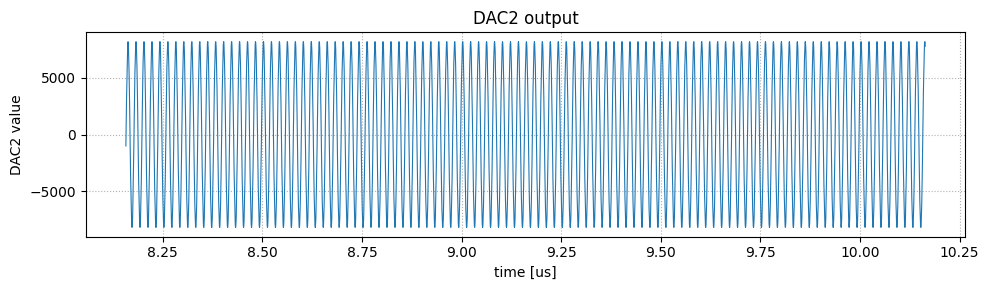

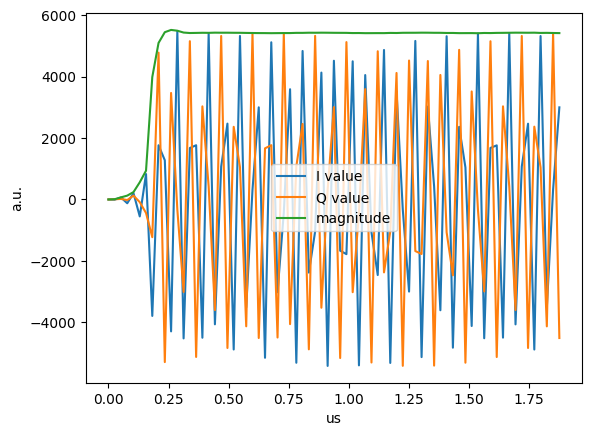

In [12]:
# emulator artifacts
OUT = ARTIFACTS_ROOT / 'MuxProgram'
OUT.mkdir(parents=True, exist_ok=True)
print(f'Artifacts -> {OUT}')

soc = soc.prepare_emu(memdir=OUT, build=True, trace=True, verbose=True)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

QICKEmu_plot_dac2(soc, OUT)

# # TODO: there's no mux readout support yet
# fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(12,12))
# for i, ch in enumerate(config['ro_chs']):
#     plot = axes[i]
#     plot.plot(t, iq_list[i][:,0], label="I value")
#     plot.plot(t, iq_list[i][:,1], label="Q value")
#     plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
#     plot.legend()
#     plot.set_ylabel("a.u.")
#     plot.set_xlabel("us");

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

In [ ]:
class MuxProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_chs[0], 
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'], 
                         mux_phases=cfg['pulse_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=gen_ch)

        self.add_pulse(ch=gen_ch, name="mymux", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0,1,2,3],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name="mymux", t=0)
        
config = {'gen_ch': FSMUXGEN_CH,
          'ro_chs': MUXRO_CH,
          'pulse_freqs': [500, 550, 600, 650],
          'pulse_gains': [1.0]*4,
          'pulse_phases': [0.0]*4,
          'ro_phases': [0.0]*4,
          'trig_time': 0.4,
          'pulse_len': 1.0,
          'ro_len': 1.9,
         }

prog = MuxProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(12,12))
for i, ch in enumerate(config['ro_chs']):
    plot = axes[i]
    plot.plot(t, iq_list[i][:,0], label="I value")
    plot.plot(t, iq_list[i][:,1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
    plot.legend()
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us");

We can calculate the phases we're seeing in the data, and use that to rotate the data onto the positive real axis. We can apply the phase correction in two ways: we can subtract it from the upconversion phase, or add it to the downconversion phase.

In [ ]:
phases = [np.angle(iq.mean(axis=0).dot([1,1j]), deg=True) for iq in iq_list]
print("phase offsets:", phases)

In [ ]:
# rotate the upconversion phase
config = {'gen_ch': FSMUXGEN_CH,
          'ro_chs': MUXRO_CH,
          'pulse_freqs': [500, 550, 600, 650],
          'pulse_gains': [1.0]*4,
          'pulse_phases': [-x for x in phases],
          'ro_phases': [0.0]*4,
          'trig_time': 0.4,
          'pulse_len': 1.0,
          'ro_len': 1.9,
         }

prog = MuxProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(12,8))
for i, ch in enumerate(config['ro_chs']):
    plot = axes[i]
    plot.plot(t, iq_list[i][:,0], label="I value")
    plot.plot(t, iq_list[i][:,1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
    plot.legend()
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us");

In [ ]:
# rotate the downconversion phase
config = {'gen_ch': FSMUXGEN_CH,
          'ro_chs': MUXRO_CH,
          'pulse_freqs': [500, 550, 600, 650],
          'pulse_gains': [1.0]*4,
          'pulse_phases': [0.0]*4,
          'ro_phases': phases,
          'trig_time': 0.4,
          'pulse_len': 1.0,
          'ro_len': 1.9,
         }

prog = MuxProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(12,8))
for i, ch in enumerate(config['ro_chs']):
    plot = axes[i]
    plot.plot(t, iq_list[i][:,0], label="I value")
    plot.plot(t, iq_list[i][:,1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
    plot.legend()
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us");

## interpolated generator and standard (PYNQ-configured) readout (almost identical to 00_intro)
The only difference between this program and the one in the 00_intro notebook is that you need to set the mixer frequency.

If you've used the interpolated generator in tProc v1, it's the same here. Remember that the digital LO is not phase-coherent with respect to frequency changes (see e.g. https://github.com/openquantumhardware/qick/issues/122). Also, a very verbose reminder of how the readout frequency is defined when you're using the digital mixer:

### frequency-matching and the digital mixer
In tProc v1, if you were using a generator with a digital mixer, you needed to specify your generator frequencies relative to the mixer frequency, as if you were setting an IF. Less intuitively, if you had a readout frequency-matched to this generator you needed to specify the readout frequency relative to the generator's mixer frequency, again as if you were setting an IF and had mixers on both sides. (See below for a long-winded explanation of why v1 worked this way.)

In tProc v2, generator and readout frequencies are always absolute, not relative to the mixer frequency; the appropriate generator IF is calculated behind the scenes. You still need to choose a mixer frequency that puts all generator frequencies in range.

#### in tProc v1
Remember that if your generator has a digital mixer and you set a nonzero `mixer_freq`, the software will add this mixer frequency to whatever readout downconversion frequency you specify.
To be precise (and assuming you requested frequency-matching - i.e. your generator declaration, your readout declaration, and your pulse definition all reference the matched channel):
* The mixer frequency is rounded (in `declare_gen()`) to a common multiple of the mixer and readout frequency step sizes.
* The pulse frequency is rounded (in `freq2reg()`) to a common multiple of the generator and readout frequency step sizes.
* The readout frequency you request is rounded (in `declare_readout()`) to a common multiple of the generator and readout frequency step sizes (the generator step size is always a multiple of the corresponding mixer's step size). Then this is added to the rounded mixer frequency, and the sum is what actually gets used for downconversion - similar to what would happen if there were also a digital mixer on the readout side.

This behavior sometimes leads to confusion:
* If you (as an experienced experimentalist) expect simple, literal "do what I asked for, not what I meant" behavior from your instruments, and you know there is no digital mixer on the readout side, you will expect your downconversion frequency to just be what you requested, and then nothing will work.
* Conversely, you might see this behavior and conclude that there is a digital mixer on both sides, maybe fed from a common oscillator, and this might lead you astray in debugging some other problem you are having.

But this behavior exists to ensure proper frequency matching. Consider this toy example with easy but fake numbers:
* Let's say all three frequencies in your system (your generator's carrier and mixer frequencies, and your readout's downconversion frequency) all have step sizes of 1 MHz.
* Let's say you (reasonably) pick your frequencies without thinking about the frequency quantization. You want a 100.3 MHz mixer frequency and a 100.3 MHz carrier frequency.
* So you would set the mixer frequency to 100.3, and use 100.3 in both the pulse and readout definitions. All three numbers will be rounded, so you will end up with:
    * Mixer at 100 MHz, carrier at 100 MHz, the digital mixer will add those and your signal will go out at 100+100 = 200 MHz.
    * The software will configure the readout at the sum of the two post-rounding values, so 100+100 = 200 MHz. Frequencies are matched and your readout will work.
* Let's suppose the software didn't add the mixer_freq to your readout frequency. So you would use 100.3 MHz for the mixer and pulse, and you will do your own math to figure out that the readout should be at 100.3+100.3 = 200.6 MHz. The result:
    * As before, mixer at 100 MHz, carrier at 100 MHz, signal will go out at 200 MHz
    * The software will round your 200.6 MHz and configure your readout at 201 MHz. You will get a frequency mismatch!
 
#### in tProc v2
This is how v2 does frequency-matching:
* As with v1, the mixer frequency is rounded when it's defined in `declare_gen()`.
* The generator manager looks at your pulse frequency, subtracts the mixer frequency, rounds what's left, and that's the frequency which actually gets applied inside the generator.
* `declare_readout()` sees that you specified a matched generator, subtracts that generator's mixer frequency from your readout frequency, rounds what's left, and adds the mixer frequency back in, and that's what gets applied in the readout. This gives you correct frequency matching.

This scheme couldn't have worked in v1 because frequency conversion for the generator was done when the user code calls `freq2reg()`; that code doesn't know what mixer frequencies have been set and very often `freq2reg()` might be run before `declare_gen()`, or even be run outside of a program.

In [ ]:
class SimpleSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_ch, mixer_freq=cfg['mixer_freq'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['freq'], gen_ch=gen_ch)

        self.add_loop("myloop", self.cfg["steps"])

        self.add_gauss(ch=gen_ch, name="ramp", sigma=cfg['ramp_len']/10, length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       length=cfg['flat_len'],
                       phase=cfg['phase'],
                       gain=cfg['gain'], 
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
# do a sweep with 5 points and plot decimated
config = {'steps': 5,
          'gen_ch': INTGEN_CH,
          'ro_ch': STDRO_CH,
          'freq': 2000,
          'mixer_freq': 1500,
          'trig_time': 0.45,
          'ro_len': 0.3,
          'flat_len': 0.05,
          'ramp_len': 0.2,
          'phase': QickSweep1D("myloop", -360, 720),
          'gain': QickSweep1D("myloop", 0.0, 1.0)
         }

prog = SimpleSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

for ii, iq in enumerate(iq_list[0]):
    plt.plot(t, iq[:,0], label="I value, step %d"%(ii))
    # plt.plot(iq[:,1], label="Q value, step %d"%(ii))
    # plt.plot(np.abs(iq.dot([1,1j])), label="mag, step %d"%(ii))
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");

In [ ]:
print(prog.get_pulse_param("mypulse","freq"))
print(prog.ro_chs[STDRO_CH]['ro_config']['f_rounded'])

In [ ]:
print(config['gain'].get_actual_values({k:n for k,n,_,_ in prog.loops}))
print(prog.get_pulse_param("mypulse","gain", as_array=True))


## standard (full-speed) gen and dynamically configured readout

If you've used the tProc-configured readout in tProc v1, it's the same here, though I'm calling it "dynamically configured" which is hopefully more descriptive.

A useful feature of dynamic readouts is that you can sweep the downconversion frequency inside your QICK program. In certain firmwares where a dynamic readout shares a fabric clock with a generator, dynamic readouts allow a synchronized phase reset; this is not supported in this demo firmware.

Anyway, the point is that this readout gets its configuration parameters (downconversion frequency, output selection, etc.) through a tProc interface, in the same way that the standard generator gets pulse parameters from the tProc. So this is how you use it:
1. Use `add_readoutconfig()` (similar to `add_pulse()`) to define a "readout config" in your program that is a lot like a pulse (it's stored as a waveform, it can be swept).
2. At some point in your program, use `send_readoutconfig()` (similar to `pulse()`) to send the config to the readout. Make sure this reaches your readout before the signal does.

Don't forget to do both steps! Your readout is not going to magically see the readout config just because you defined it. Nor will it get sweep updates - if you sweep a readout parameter, you need to send the config to your readout at each sweep step (typically you can just do this at start-of-shot).

By the way - for the other ("PYNQ-configured") readouts, you put your readout parameters in declare_readout(). Those parameters do not go in the assembly code; they are written directly to the readout block (through the PYNQ interface) before the program is executed, and you can't change those parameters while your program is running. You can make an analogy to the mux generator's frequency+gain parameters (which are set through PYNQ).

### a little note about how/why the fast dynamic readout is weird
The dynamic readout comes in two flavors, the "standard" dynamic readout (axis_dyn_readout_v1) and the "fast" dynamic readout (axis_readout_v3). The dynamic RO was designed as a phase-resettable readout for applications (e.g. the three-wave mixing readout in https://arxiv.org/abs/2311.17171, or the laser stabilization in https://github.com/openquantumhardware/qick/issues/120) where you need to phase-reset the generator that's playing your readout tone, and therefore need to simultaneously reset the readout phase. This only works if the gen and RO share their fabric clock. With the standard dynamic RO, this implies fs\_DAC = 2\*fs\_ADC; for ZCU216 this would mean a generator sampling frequency of <5 Gsps, which is not great for many applications. The fast dynamic RO doubles the fabric clock, and therefore expects fs\_DAC = 4\*fs\_ADC, which lets you run both the gen+RO at the ZCU216's maximum speed.

The clock doubling makes the fast dynamic readout a little weird:
* Compared to the other readouts, it's relatively annoying to put this one in a firmware.
* It only downsamples the ADC by 4 as opposed to 8. This improves your time resolution but raises the cutoff of the decimation filter.
    * You probably don't care about the time resolution.
    * You may care about the decimation cutoff, because you rely on that filter to kill the image tone described in https://github.com/openquantumhardware/qick/blob/main/qick_demos/08_Special_buffers.ipynb. In other words, you need more separation between your readout tone and the ADC's Nyquist zone boundaries: roughly fs/16 instead of fs/32 (https://github.com/openquantumhardware/qick/issues/120#issuecomment-1494931618).
 
<!-- If there is big demand for a sweepable readout that isn't weird but doesn't have a synchronized phase-reset, it's doable - let us know. (Technically you could still sync the phase-reset, but with a requirement of  as opposed to fs\_DAC = 4\*fs\_ADC, and most people want their DACs to be faster than that.) -->

### basic loopback
Here the readout parameters aren't swept, so we can both define them and set them in `_initialize()`.

Note that I put definitions (these add stuff to the program metadata - generally they start with "add" or "declare") before the tProc instructions (these add ASM instructions to the program, which are executed by the tProc) in `_initialize()`. This isn't a rule, but it's good code hygiene to sort of separate the "setup" stuff from the code that actually runs as part of your experiment sequence. (As an example of what not to do? You can put definitions in the `_body()` and your program will work fine! Definitions do their thing when the Python interpreter sees them during compilation, so your tProc loops have no effect on them. But it will look very strange.)

In [ ]:
class SimpleSweepProgram2(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop("myloop", self.cfg["steps"])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch)

        self.add_gauss(ch=gen_ch, name="ramp", sigma=cfg['ramp_len']/10, length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       length=cfg['flat_len'],
                       phase=cfg['phase'],
                       gain=cfg['gain'], 
                      )

        
        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

In [ ]:
# do a sweep with 5 points and plot decimated
config = {'steps': 5,
          'gen_ch': FSGEN_CH,
          'ro_ch': DYNRO_CH,
        #   'freq': 1500,
          'freq': 100,
          'nqz': 1,
          'trig_time': 0.4,
          'ro_len': 0.3,
          'flat_len': 0.05,
          'ramp_len': 0.2,
          'phase': QickSweep1D("myloop", -360, 720),
          'gain': QickSweep1D("myloop", 0.0, 1.0)
         }

# emulator artifacts
OUT = ARTIFACTS_ROOT / 'SimpleSweepProgram2'
OUT.mkdir(parents=True, exist_ok=True)

soc = soc.prepare_emu(memdir=OUT, trace=False, verbose=True)
print(f'Artifacts -> {OUT}')

prog = SimpleSweepProgram2(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

## Plot DAC waveform
QICKEmu_plot_dac(soc, OUT)


for ii, iq in enumerate(iq_list[0]):
    plt.plot(t, iq[:,0], label="I value, step %d"%(ii))
    # plt.plot(t, iq[:,1], label="Q value, step %d"%(ii))
    # plt.plot(t, np.abs(iq.dot([1,1j])), label="mag, step %d"%(ii))
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");


### frequency sweeping
Now we'll sweep the upconversion and downconversion frequencies together. Note that we therefore need to run `send_readoutconfig()` inside the loop where the frequency gets swept; we accomplish this by putting it in that loop's `exec_before`, though you could also put it at the beginning of your `_body()`.

We'll start with a small frequency range.

In [ ]:
START_FREQ = 100
CAL_RANGE = 1
END_FREQ = 8000

class FreqSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=cfg['nqz'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch)
        
        loopbefore = AsmV2()
        # if you delay the config by too long, you can see the readout get reconfigured in the middle of your pulse
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("myloop", self.cfg["steps"], exec_before=loopbefore)

        self.add_gauss(ch=gen_ch, name="ramp", sigma=cfg['ramp_len']/10, length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       length=cfg['flat_len'],
                       phase=cfg['phase'],
                       gain=cfg['gain'], 
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# do a sweep with 5 points and plot decimated
config = {'steps': 5,
          'gen_ch': FSGEN_CH,
          'ro_ch': DYNRO_CH,
          'freq': QickSweep1D("myloop", START_FREQ, START_FREQ+CAL_RANGE),
          'nqz': 1,
          'trig_time': 0.4,
          'ro_len': 0.3,
          'flat_len': 0.05,
          'ramp_len': 0.2,
          'phase': 0,
          'gain': 1.0
         }

# emulator artifacts
OUT = ARTIFACTS_ROOT / 'FreqSweepProgram'
OUT.mkdir(parents=True, exist_ok=True)

soc = soc.prepare_emu(memdir=OUT, trace=False, verbose=True)
print(f'Artifacts -> {OUT}')

prog = FreqSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=10)
t = prog.get_time_axis(ro_index=0)

## Plot DAC waveform
QICKEmu_plot_dac(soc, OUT)

for ii, iq in enumerate(iq_list[0]):
    plt.plot(t, iq[:,0], label="I value, step %d"%(ii))
    # plt.plot(t, iq[:,1], label="Q value, step %d"%(ii))
    # plt.plot(t, np.abs(iq.dot([1,1j])), label="mag, step %d"%(ii))
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");

In [ ]:
print(config['freq'].get_actual_values({k:n for k,n,_,_ in prog.loops}))
print(prog.get_pulse_param("mypulse","freq", as_array=True))


Now let's do small steps. As you know from the "phase coherence" demo (demo 01 in qick_demos), frequency sweeps give you a rotating phase because the upconversion and downconversion LOs have different start times.

In [ ]:
config['steps']=100001
config['steps']=1001

# emulator artifacts
OUT = ARTIFACTS_ROOT / 'FreqSweepProgram'
OUT.mkdir(parents=True, exist_ok=True)

soc = soc.prepare_emu(memdir=OUT, trace=False, verbose=False)
print(f'Artifacts -> {OUT}')


prog = FreqSweepProgram(soccfg, reps=10, final_delay=1.0, cfg=config)
freqs = prog.get_pulse_param('myro', 'freq', as_array=True)
iq_list = prog.acquire(soc, rounds=1, progress=True)

# plt.plot(np.angle(iq_list[0][0].dot([1,1j]), deg=True))
plt.plot(iq_list[0][0,:,0], iq_list[0][0,:,1], '.')
plt.ylabel("Q [ADU]")
plt.xlabel("I [ADU]");

We can plot the phase vs. frequency. Note that because our sweep steps are very small, and the sweep step needs to be rounded to the frequency-matching step size, the sweep range is noticeably different from what we asked for. (If this was a problem, you could adjust the step count to bring your nominal step size closer to the rounded value.)

Anyway, the phase difference between consecutive points is very small, which gives us confidence that we're measuring the phase rotation correctly and not getting something aliased.

In [ ]:
iq_complex = iq_list[0][0].dot([1,1j])
phases = np.unwrap(np.angle(iq_complex))/(2*np.pi)

plt.plot(freqs, phases)
plt.ylabel("Phase [cycles]")
plt.xlabel("Frequency [MHz]")

print("phase step (cycles):", phases[1]-phases[0])

We can do a linear least-squares fit to get the slope, which we can interpret as a delay. (Your VNA would call this an "electrical delay" calibration.)

In [ ]:
a = np.vstack([freqs, np.ones_like(freqs)]).T
phase_delay = np.linalg.lstsq(a, phases, rcond=None)[0][0]
print("relative delay %.4f us"%(phase_delay))

Now let's do a wide-range sweep and use the calibration to remove the phase delay.

In [ ]:
config['freq'] = QickSweep1D("myloop", START_FREQ, END_FREQ)
config['steps'] = 10001
# freqs = np.linspace(START_FREQ, END_FREQ, config['steps'])

prog = FreqSweepProgram(soccfg, reps=100, final_delay=1.0, cfg=config)
freqs = prog.get_pulse_param('myro', 'freq', as_array=True)
iq_list = prog.acquire(soc, rounds=1, progress=True)
iq_complex = iq_list[0][0].dot([1,1j])


iq_rotated = iq_complex*np.exp(-1j*freqs*2*np.pi*phase_delay)
plt.plot(np.real(iq_rotated), np.imag(iq_rotated))
plt.ylabel("Q [ADU]")
plt.xlabel("I [ADU]");

Plot the amplitude and phase: we can see the resonator at 940 MHz as a dip in magnitude and a pi rotation in the phase. As an open-ended quater-wave resonator, it resonates at all odd multiples of 940 MHz and you also see it at 2.8 GHz, 4.7 GHz, etc.

By the way - notice that the spectrum is mirrored around 4.9 GHz. This happens because the DAC sampling frequency is 4 times that of the ADC, and 4.9 GHz is a Nyquist zone boundary for both. (The old ZCU111 standard firmware also had this property; the DAC sampling frequency was double that of the ADC.) In general, DACs and ADCs cannot distinguish between Nyquist images (that's essentially the definition of a Nyquist zone). So:
* Whether you ask the generator to play 4.9-x or 4.9+x, the DAC will play both. Whether you ask the readout to downconvert at 4.9-x or 4.9+x, it will be sensitive to both. The first tone is in the DAC's 1st Nyquist zone and the ADC's 4th/3rd/2nd/1st Nyquist zone, the second is in the DAC's 2nd Nyquist zone and the ADC's 5th/6th/7th/8th.
* The transmission value you measure will be the sum of the two tones.
* Filtering (the DAC's `nqz` setting, the analog response of the DAC and ADC, the balun response, and any other analog filtering) changes the relative strength and transmission of the two tones. Here the resonance is in a region where the `nqz` setting, analog response, and balun response strongly favor the 940 MHz tone over the 9 GHz tone, so we mostly just see the 940 MHz response. Were that not the case, the resonance would be largely washed out by transmission at the other tone.

More generally, in a serious measurement you always want to filter, even if your firmware does not have this simple-multiples relation between DAC and ADC sampling frequencies:
* Filter your DAC to remove any unwanted Nyquist images which could otherwise saturate your amplifiers, create spurs in your mixers, and do weird things to your device.
* Filter your ADC to ensure that it sees your measurement tone but is blind to the noise at any of its Nyquist images.
* If your operating frequency is close to a DAC or ADC Nyquist boundary, it's going to be very difficult to filter appropriately. You should consider changing the sampling frequency (this requires recompiling the firmware).

In [ ]:
phases_corrected = np.unwrap(np.angle(iq_rotated))/(2*np.pi)

fig, plot = plt.subplots()
plot.semilogy(freqs, np.abs(iq_rotated), label="amplitude")
ax2 = plot.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(freqs, phases_corrected, color='red', label='phase')

plot.set_ylabel("amplitude [ADU]")
plot.set_xlabel("frequency [MHz]")
ax2.set_ylabel("phase [cycles]");

Note that instead of correcting the phase of the data, you could use a phase sweep in the pulse or the readout config. There's no obvious advantage in this case (or ever?), so it's left as an exercise for the reader.

## extra: readout IQ offsets

Some of the readout blocks (not the standard one, but basically everything else) put small nonzero offsets on the I and Q values. For example, the muxed readouts give you I and Q centered around -0.5 in the absence of a signal. This is an artifact of how the ADC values get truncated. If you don't correct for this effect, it shows up in strange ways, usually as a oscillating amplitude vs. freq for very small signals: your signal is small, it rotates in the IQ plane as your frequency changes, the offset is always (-0.5, -0.5) so the offset will sometimes add to your signal and sometimes subtract.

Anyway, we very recently (https://github.com/openquantumhardware/qick/pull/254) added a software workaround for this - `acquire()` and `acquire_decimated()` will subtract out the offsets. The raw data arrays are not subtracted, and if you do feedback your tProc input will also see the raw value without subtraction.

Here are two simple programs that do long readouts with no pulse playing, to measure the offsets in the raw data (and you can see that the output of `acquire()` doesn't have the offset).

In [ ]:
class TestProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        for ch in cfg['ro_chs']:
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=100)

    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], t=0.0)
        
config = {
    'ro_chs': MUXRO_CH+[STDRO_CH],
    'ro_len': 100.0,
 }

prog = TestProgram(soccfg, reps=1000, final_delay=0.5, cfg=config)

iq_list = prog.acquire(soc, rounds=1)
print("IQ offsets:", iq_list)

iq_raw = prog.get_raw()

nch = len(prog.ro_chs)
fig, axes = plt.subplots(2*nch, 1, figsize=(12,3*nch))
for i, (ch, rocfg) in enumerate(prog.ro_chs.items()):
    
    offset = soccfg['readouts'][ch]['iq_offset']
    bins = np.linspace(offset-0.1, offset+0.1, 101)
    nsamp = rocfg['length']
    plot = axes[2*i]
    plot.hist(iq_raw[i][:,0,0]/nsamp, bins=bins);
    plot = axes[2*i+1]
    plot.hist(iq_raw[i][:,0,1]/nsamp, bins=bins);

In [ ]:
class TestProgram2(AveragerProgramV2):
    def _initialize(self, cfg):
        for ch in cfg['ro_chs']:
            confname = "myro%d" % (ch)
            self.declare_readout(ch=ch, length=cfg['ro_len'])
    
            self.add_readoutconfig(ch=ch, name=confname, freq=100)
            self.send_readoutconfig(ch=ch, name=confname, t=0)
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'],  t=0)

config = {
    'ro_chs': [DYNRO_CH, FASTDYNRO_CH],
    'ro_len': 100.0,
 }

prog = TestProgram2(soccfg, reps=1000, final_delay=0.5, cfg=config)

iq_list = prog.acquire(soc, rounds=1)
print(iq_list)

iq_raw = prog.get_raw()

nch = len(prog.ro_chs)
fig, axes = plt.subplots(2*nch, 1, figsize=(12,3*nch))
for i, (ch, rocfg) in enumerate(prog.ro_chs.items()):
    
    offset = soccfg['readouts'][ch]['iq_offset']
    bins = np.linspace(offset-0.1, offset+0.1, 101)
    nsamp = rocfg['length']
    plot = axes[2*i]
    plot.hist(iq_raw[i][:,0,0]/nsamp, bins=bins);
    plot = axes[2*i+1]
    plot.hist(iq_raw[i][:,0,1]/nsamp, bins=bins);

## extra: testing all gen+RO combinations
There are 4 generators (if you count the mixer-mux and fullspeed-mux as different generators) and 3 readouts (the two dynamic readouts have identical software interfaces), so in principle that's 12 combinations: three are covered above, the combination of full-speed gen + standard RO is covered in the 00_intro notebook. Here are the other 8 - you will need to swap cables to see the pulses.

Let's also check (for fun, or to test the frequency-matching code) that the generator and readout frequencies are matched. Because of floating-point math, the frequencies won't always come to exactly the same number, but if the difference is less than 1e-12 MHz you are probably actually matched (the smallest frequency steps are the mixer steps and those are fs/2^48, typically ~2e-11 MHz; Python float precision is ~1 part in 2^53, <1e-12 MHz).

In [ ]:
class FSMuxGenStdROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_ch,
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'], 
                         mux_phases=cfg['pulse_phases'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['pulse_freqs'][0], phase=cfg['ro_phase'], gen_ch=gen_ch)

        self.add_pulse(ch=gen_ch, name="mypulse", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0],
                      )

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)

config = {'gen_ch': FSMUXGEN_CH,
          'ro_ch': STDRO_CH,
          'pulse_freqs': [1500.1],
          'pulse_gains': [1.0],
          'pulse_phases': [0.0],
          'ro_phase': 0.0,
          'trig_time': 0.2,
          'pulse_len': 1.0,
          'ro_len': 1.9,
         }

prog = FSMuxGenStdROProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

iq = iq_list[0]
plt.plot(t, iq[:,0], label="I value")
plt.plot(t, iq[:,1], label="Q value")
plt.plot(t, np.abs(iq.dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");

# frequency-matching cross-check
# prog.reg2freq(prog.gen_chs[config['gen_ch']]['mux_tones'][0]['freq_int'], config['gen_ch'])
# prog.reg2freq_adc(prog.ro_chs[config['ro_ch']]['ro_config']['f_int'], config['ro_ch'])
f_gen = prog.gen_chs[config['gen_ch']]['mux_tones'][0]['freq_rounded']
f_ro = prog.ro_chs[config['ro_ch']]['ro_config']['f_rounded']
print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

In [ ]:
class FSMuxGenDynROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_ch,
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'], 
                         mux_phases=cfg['pulse_phases'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['pulse_freqs'][0], phase=cfg['ro_phase'], gen_ch=gen_ch)

        self.add_pulse(ch=gen_ch, name="mypulse", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0],
                      )

        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        
    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        
config = {'gen_ch': FSMUXGEN_CH,
          'ro_ch': DYNRO_CH,
          'pulse_freqs': [1500],
          'pulse_gains': [1.0],
          'pulse_phases': [0.0],
          'ro_phase': 0.0,
          'trig_time': 0.2,
          'pulse_len': 0.5,
          'ro_len': 1.0,
         }

prog = FSMuxGenDynROProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

iq = iq_list[0]
plt.plot(t, iq[:,0], label="I value")
plt.plot(t, iq[:,1], label="Q value")
plt.plot(t, np.abs(iq.dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");

# frequency-matching cross-check
f_gen = prog.gen_chs[config['gen_ch']]['mux_tones'][0]['freq_rounded']
f_ro = prog.get_pulse_param('myro','freq')
print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

In [ ]:
class FullspeedGenMuxROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['pulse_freq'], phase=cfg['ro_phase'], gen_ch=gen_ch)

        self.add_gauss(ch=gen_ch, name="ramp", sigma=cfg['ramp_len']/10, length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['pulse_freq'], 
                       length=cfg['flat_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['pulse_gain'], 
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

config = {'gen_ch': FSGEN_CH,
          'ro_ch': MUXRO_CH[0],
          'pulse_freq': 1500,
          'trig_time': 0.45,
          'ro_len': 1.9,
          'flat_len': 0.2,
          'ramp_len': 1.0,
          'pulse_phase': 0.0,
          'pulse_gain': 1.0,
          'ro_phase': 0.0,
         }

prog = FullspeedGenMuxROProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

iq = iq_list[0]
plt.plot(t, iq[:,0], label="I value")
plt.plot(t, iq[:,1], label="Q value")
plt.plot(t, np.abs(iq.dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");

# frequency-matching cross-check
f_gen = prog.get_pulse_param('mypulse','freq')
f_ro = prog.ro_chs[config['ro_ch']]['ro_config']['f_rounded']
print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

In [ ]:
class IntGenMuxROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1, mixer_freq=cfg['mixer_freq'], ro_ch=ro_ch
                        )
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['pulse_freq'], phase=cfg['ro_phase'], gen_ch=gen_ch)

        self.add_gauss(ch=gen_ch, name="ramp", sigma=cfg['ramp_len']/10, length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['pulse_freq'], 
                       length=cfg['flat_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['pulse_gain'], 
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

config = {'gen_ch': INTGEN_CH,
          'ro_ch': MUXRO_CH[0],
          'pulse_freq': 1500,
          'mixer_freq': 1000,
          'pulse_phase': 0.0,
          'pulse_gain': 1.0,
          'trig_time': 0.45,
          'ro_len': 1.9,
          'flat_len': 0.2,
          'ramp_len': 1.0,
          'ro_phase': 0.0,
         }

prog = IntGenMuxROProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

iq = iq_list[0]
plt.plot(t, iq[:,0], label="I value")
plt.plot(t, iq[:,1], label="Q value")
plt.plot(t, np.abs(iq.dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");

# frequency-matching cross-check
f_gen = prog.get_pulse_param('mypulse','freq')
f_ro = prog.ro_chs[config['ro_ch']]['ro_config']['f_rounded']
print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

In [ ]:
class IntGenDynROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1, mixer_freq=cfg['mixer_freq'], ro_ch=ro_ch)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['pulse_freq'], phase=cfg['ro_phase'], gen_ch=gen_ch)

        loopbefore = AsmV2()
        # if you delay the config by too long, you can see the readout get reconfigured in the middle of your pulse
        loopbefore.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        self.add_loop("myloop", self.cfg["steps"], exec_before=loopbefore)
        
        self.add_gauss(ch=gen_ch, name="ramp", sigma=cfg['ramp_len']/10, length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['pulse_freq'], 
                       length=cfg['flat_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['pulse_gain'], 
                      )

        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        
    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        
config = {'steps': 5,
          'gen_ch': INTGEN_CH,
          'ro_ch': DYNRO_CH,
          'pulse_freq': QickSweep1D("myloop", 1500, 1501),
          'mixer_freq': 1000,
          'pulse_phase': 0.0,
          'pulse_gain': 1.0,
          'ro_phase': 0.0,
          'trig_time': 0.2,
          'flat_len': 0.05,
          'ramp_len': 0.2,
          'ro_len': 0.3,
         }

prog = IntGenDynROProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

for ii, iq in enumerate(iq_list[0]):
    plt.plot(t, iq[:,0], label="I value, step %d"%(ii))
    # plt.plot(t, iq[:,1], label="Q value, step %d"%(ii))
    # plt.plot(t, np.abs(iq.dot([1,1j])), label="mag, step %d"%(ii))
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");

# iq = iq_list[0]
# plt.plot(t, iq[:,0], label="I value")
# plt.plot(t, iq[:,1], label="Q value")
# plt.plot(t, np.abs(iq.dot([1,1j])), label="mag")
# plt.legend()
# plt.ylabel("amplitude [ADU]")
# plt.xlabel("time [us]");

# frequency-matching cross-check
f_gen = prog.get_pulse_param('mypulse','freq', as_array=True)
f_ro = prog.get_pulse_param('myro','freq', as_array=True)
print("pulse freq %s MHz, RO freq %s MHz, difference %s MHz"%(f_gen, f_ro, f_gen-f_ro))

In [ ]:
class MixMuxGenMuxROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'],)
        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=gen_ch)

        self.add_pulse(ch=gen_ch, name="mymux", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0,1,2,3],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name="mymux", t=0)
        
config = {'gen_ch': MIXMUXGEN_CH,
          'ro_chs': MUXRO_CH,
          'pulse_freqs': [1500, 1550, 1600, 1650],
          'mixer_freq': 1000,
          'pulse_gains': [1.0]*4,
          'pulse_phases': [0.0]*4,
          'ro_phases': [0.0]*4,
          'trig_time': 0.4,
          'pulse_len': 1.0,
          'ro_len': 1.9,
         }

prog = MixMuxGenMuxROProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(10,10))
for i, ch in enumerate(config['ro_chs']):
    plot = axes[i]
    plot.plot(t, iq_list[i][:,0], label="I value")
    plot.plot(t, iq_list[i][:,1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
    plot.legend()
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us");

for i, ch in enumerate(config['ro_chs']):
    # frequency-matching cross-check
    f_gen = prog.gen_chs[config['gen_ch']]['mux_tones'][i]['freq_rounded']
    f_ro = prog.ro_chs[ch]['ro_config']['f_rounded']
    print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

In [ ]:
prog.gen_chs

In [ ]:
class MixMuxGenStdROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_ch, 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'],)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['pulse_freqs'][0], phase=cfg['ro_phase'], gen_ch=gen_ch)

        self.add_pulse(ch=gen_ch, name="mypulse", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0],
                      )

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)

config = {'gen_ch': MIXMUXGEN_CH,
          'ro_ch': STDRO_CH,
          'mixer_freq': 1000,
          'pulse_freqs': [1500],
          'pulse_gains': [1.0],
          'pulse_phases': [0.0],
          'ro_phase': 0.0,
          'trig_time': 0.2,
          'pulse_len': 1.0,
          'ro_len': 1.9,
         }

prog = MixMuxGenStdROProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

iq = iq_list[0]
plt.plot(t, iq[:,0], label="I value")
plt.plot(t, iq[:,1], label="Q value")
plt.plot(t, np.abs(iq.dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");

# frequency-matching cross-check
f_gen = prog.gen_chs[config['gen_ch']]['mux_tones'][0]['freq_rounded']
f_ro = prog.ro_chs[config['ro_ch']]['ro_config']['f_rounded']
print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

In [ ]:
class MixMuxGenDynROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_ch,
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'],)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['pulse_freqs'][0], phase=cfg['ro_phase'], gen_ch=gen_ch)

        self.add_pulse(ch=gen_ch, name="mypulse", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0],
                      )

        self.send_readoutconfig(ch=cfg['ro_ch'], name="myro", t=0)
        
    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        
config = {'gen_ch': MIXMUXGEN_CH,
          'ro_ch': DYNRO_CH,
          'mixer_freq': 1000,
          'pulse_freqs': [1500],
          'pulse_gains': [1.0],
          'pulse_phases': [0.0],
          'ro_phase': 0.0,
          'trig_time': 0.2,
          'pulse_len': 0.5,
          'ro_len': 1.0,
         }

prog = MixMuxGenDynROProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

iq = iq_list[0]
plt.plot(t, iq[:,0], label="I value")
plt.plot(t, iq[:,1], label="Q value")
plt.plot(t, np.abs(iq.dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("amplitude [ADU]")
plt.xlabel("time [us]");

# frequency-matching cross-check
f_gen = prog.gen_chs[config['gen_ch']]['mux_tones'][0]['freq_rounded']
f_ro = prog.get_pulse_param('myro','freq')
print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

### extra: mux gen offset?

In [ ]:
from tqdm.auto import tqdm

class MuxProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_chs[0], 
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'], 
                         mux_phases=cfg['pulse_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=gen_ch)

        self.add_pulse(ch=gen_ch, name="mymux", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name="mymux", t=0)
        
config = {'gen_ch': FSMUXGEN_CH,
          'ro_chs': [MUXRO_CH[0]],
          'pulse_freqs': [500]*8,
          'pulse_gains': [0.0]*8,
          'pulse_phases': [0.0]*8,
          'ro_phases': [0.0]*8,
          'trig_time': 0.4,
          'pulse_len': 100.0,
          'ro_len': 100.9,
         }

iqs = []
gains = []
for i in tqdm(list(range(32)) + [2**i for i in range(5,15)]):
    gain = i/2**15
    config['pulse_gains'][0] = gain
    prog = MuxProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
    iq_list = prog.acquire(soc, rounds=1, progress=False)
    t = prog.get_time_axis(ro_index=0)
    gain_int = prog.gen_chs[FSMUXGEN_CH]['mux_tones'][0]['gain_int']
    print(i, gain, gain_int, iq_list[0][0])
    gains.append(gain_int)
    iqs.append(iq_list[0][0])

iqs = np.array(iqs)
plt.loglog(gains, iqs[:,0]*np.sign(iqs[-1,0]), marker='.', label='I')
plt.loglog(gains, iqs[:,1]*np.sign(iqs[-1,1]), marker='.', label='Q')
plt.xlabel("gain int")
plt.legend();

In [ ]:
plt.plot(iqs[:,0], iqs[:,1], marker='.')
plt.xlim((-5,5))
plt.ylim((-5,5))
plt.xlabel("I")
plt.ylabel("Q");